# Logistic Regression

## Problem

The objective of this project is to build a Logistic Regression model
to predict whether a loan application will be approved or not.

The target variable is `Loan_Status`.

- `Y` = Loan Approved
- `N` = Loan Not Approved

The project follows five major steps:

1. Exploratory Data Analysis (EDA)
2. Data Cleaning
3. Data Preprocessing
4. Logistic Regression Model Training
5. Model Evaluation and Results

## Data

The dataset used for this project is the Loan Prediction dataset.

The dataset contains information about applicants such as:

- Gender
- Married
- Dependents
- Education
- Self Employment
- Applicant Income
- Coapplicant Income
- Loan Amount
- Loan Amount Term
- Credit History
- Property Area
- Loan Status

The `Loan_Status` column is the target variable that we want to predict.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 614
Number of columns: 13


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


# 1. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the dataset,
identify patterns, examine distributions, and find possible outliers
before building the machine learning model.

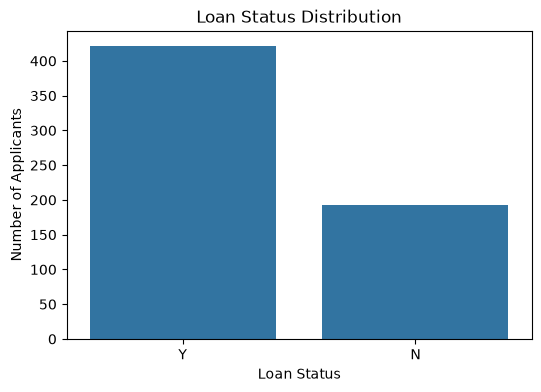

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Loan_Status"
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

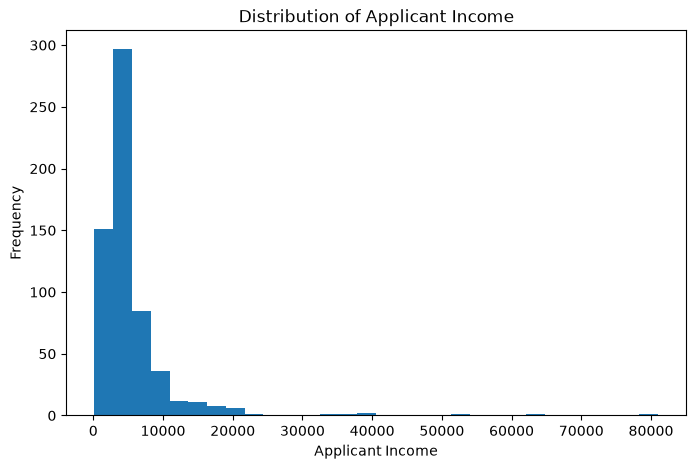

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["ApplicantIncome"],
    bins=30
)

plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

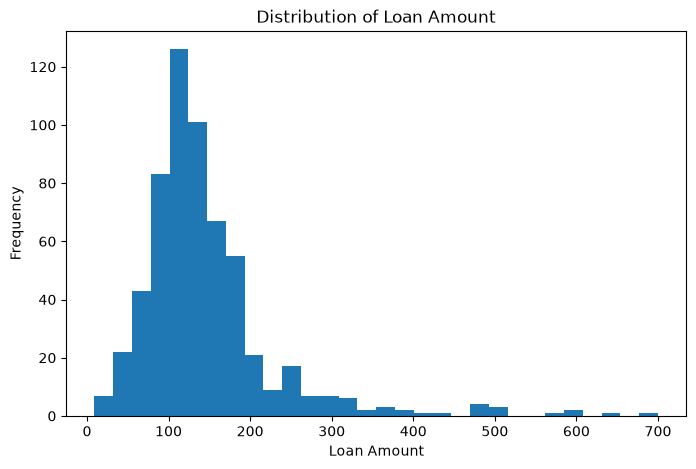

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["LoanAmount"].dropna(),
    bins=30
)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

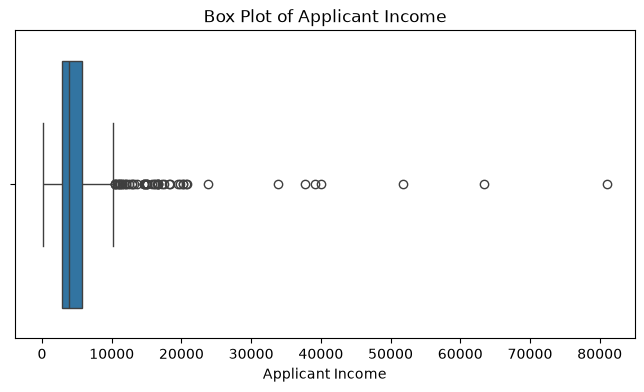

In [9]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["ApplicantIncome"]
)

plt.title("Box Plot of Applicant Income")
plt.xlabel("Applicant Income")

plt.show()

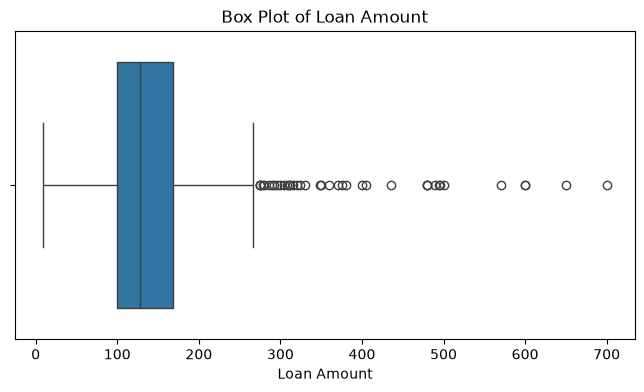

In [10]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["LoanAmount"]
)

plt.title("Box Plot of Loan Amount")
plt.xlabel("Loan Amount")

plt.show()

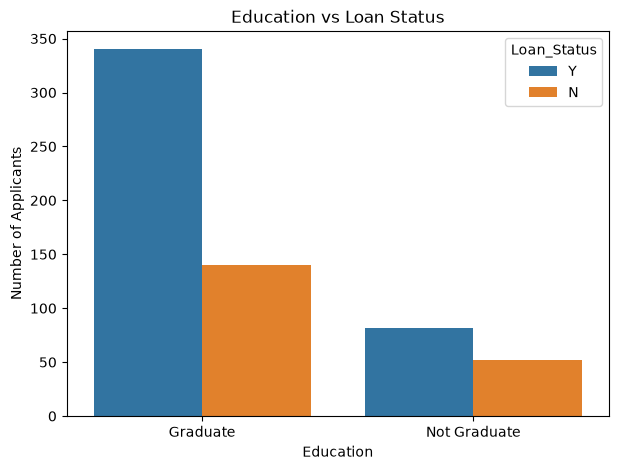

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Education",
    hue="Loan_Status"
)

plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")

plt.show()

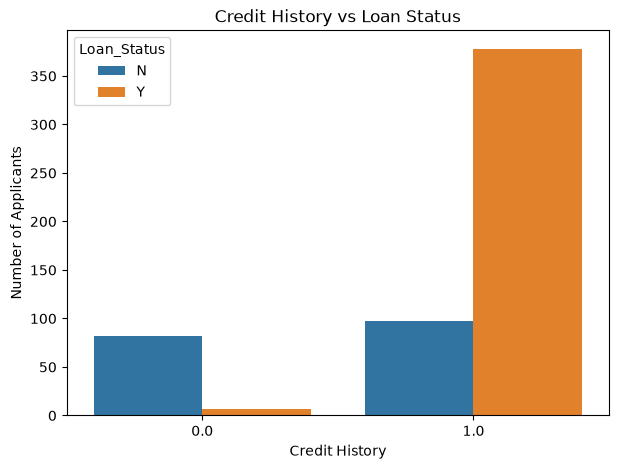

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status"
)

plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")

plt.show()

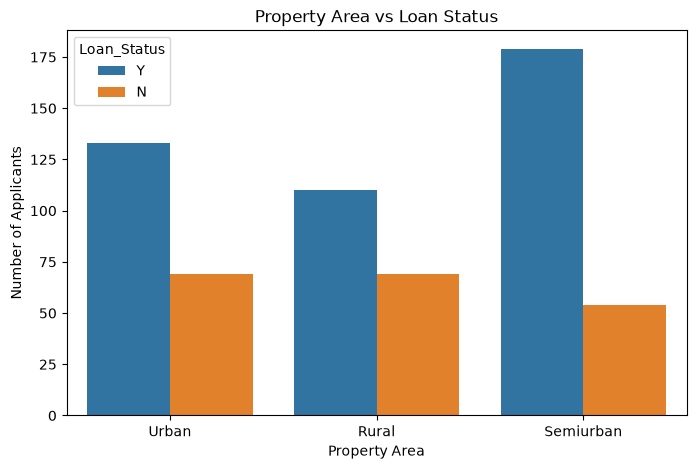

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status"
)

plt.title("Property Area vs Loan Status")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")

plt.show()

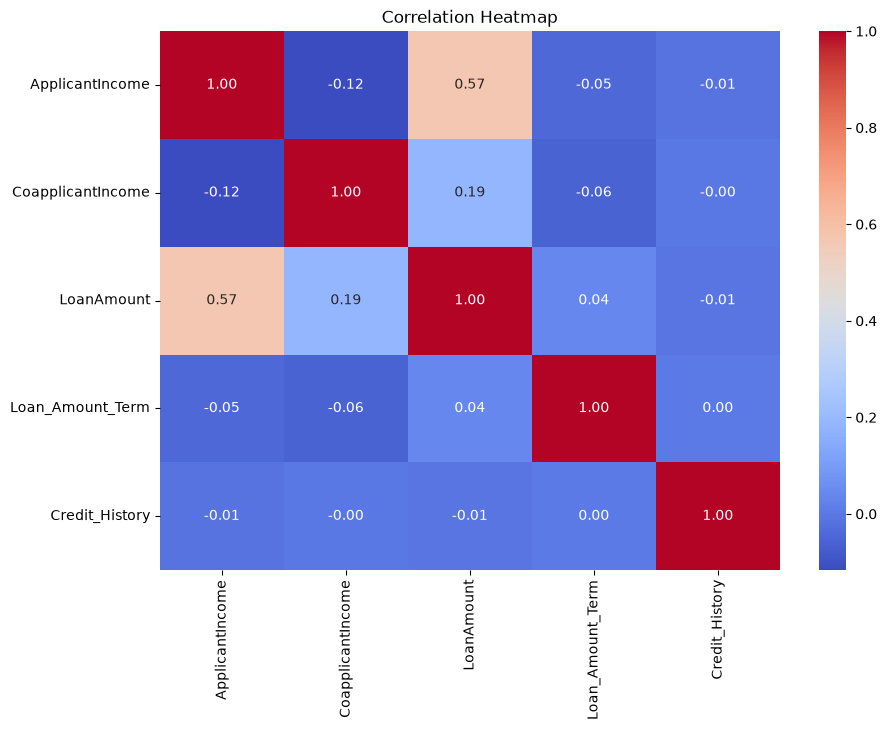

In [14]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# 2. Data Cleaning

Data cleaning is performed to identify and handle missing values,
duplicate records, and inconsistencies in the dataset before
building the machine learning model.

In [15]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Credit_History       8.143322
Self_Employed        5.211726
LoanAmount           3.583062
Dependents           2.442997
Loan_Amount_Term     2.280130
Gender               2.117264
Married              0.488599
Education            0.000000
Loan_ID              0.000000
CoapplicantIncome    0.000000
ApplicantIncome      0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

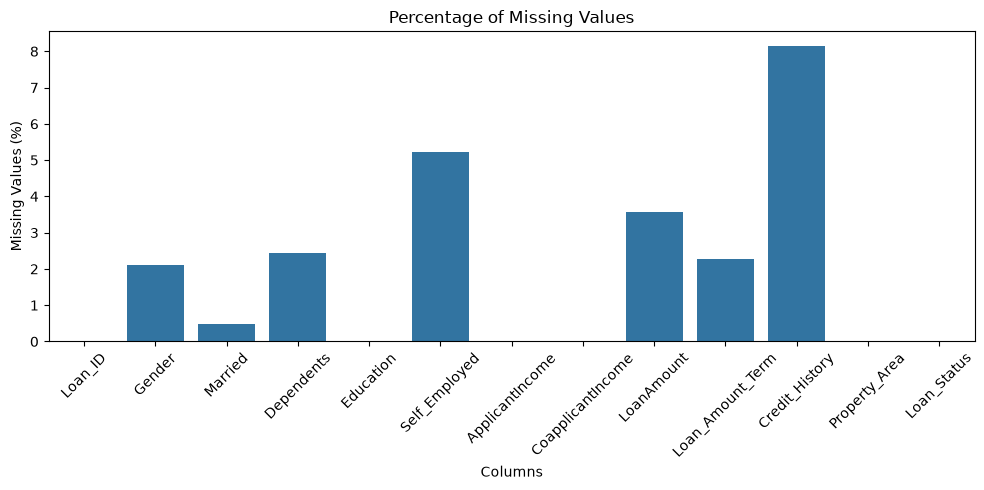

In [17]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_percentage.index,
    y=missing_percentage.values
)

plt.xticks(rotation=45)
plt.title("Percentage of Missing Values")
plt.xlabel("Columns")
plt.ylabel("Missing Values (%)")

plt.tight_layout()
plt.show()

In [18]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [19]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (614, 13)


In [20]:
df["LoanAmount"] = df["LoanAmount"].fillna(
    df["LoanAmount"].median()
)

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(
    df["Loan_Amount_Term"].median()
)

In [21]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Credit_History"
]

for column in categorical_columns:
    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

In [22]:
print("Missing values after cleaning:")

df.isnull().sum()

Missing values after cleaning:


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


# 3. Data Preprocessing

Data preprocessing is performed to convert the cleaned dataset into
a suitable format for machine learning.

The preprocessing steps include removing unnecessary columns,
separating the target variable, encoding categorical variables,
splitting the dataset, and scaling numerical features.

In [24]:
df = df.drop("Loan_ID", axis=1)

print("Loan_ID removed successfully.")

Loan_ID removed successfully.


In [25]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [26]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 11)
Target shape: (614,)


In [27]:
y = y.map({
    "Y": 1,
    "N": 0
})

print(y.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [28]:

categorical_columns = X.select_dtypes(
    include=["object"]).columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='str')


C:\Users\risha\AppData\Local\Temp\ipykernel_27296\3042211690.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [29]:
numerical_columns = X.select_dtypes(
    include=np.number
).columns

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')


In [30]:

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after encoding:", X.shape)

Shape after encoding: (614, 14)


In [31]:
X.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True


In [32]:
X.dtypes

ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Gender_Male                   bool
Married_Yes                   bool
Dependents_1                  bool
Dependents_2                  bool
Dependents_3+                 bool
Education_Not Graduate        bool
Self_Employed_Yes             bool
Property_Area_Semiurban       bool
Property_Area_Urban           bool
dtype: object

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 14)
Testing data: (123, 14)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [35]:
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (491, 14)
X_test shape: (123, 14)
y_train shape: (491,)
y_test shape: (123,)


# 4. Train a Logistic Regression Model

Logistic Regression is a classification algorithm used to predict
the probability of an observation belonging to a particular class.

In this project, the model is used to predict whether a loan application
will be approved or not.

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


In [38]:
model.fit(
    X_train_scaled,
    y_train
)

print("Model training completed successfully.")

Model training completed successfully.


In [39]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


In [40]:
print("Predicted values:")
print(y_pred[:10])

print("\nActual values:")
print(y_test.iloc[:10].values)

Predicted values:
[0 1 1 1 1 1 1 1 1 1]

Actual values:
[0 1 1 1 1 0 1 1 1 1]


In [41]:
y_probability = model.predict_proba(X_test_scaled)

print(y_probability[:5])

[[0.94668883 0.05331117]
 [0.10339024 0.89660976]
 [0.25364282 0.74635718]
 [0.29076017 0.70923983]
 [0.11115694 0.88884306]]


# 5. Model Evaluation and Results

The trained Logistic Regression model is evaluated using several
classification metrics.

The evaluation metrics used are:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report
- Cross-Validation Score

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [43]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
print("Accuracy: {:.2%}".format(accuracy))

Accuracy: 0.8617886178861789
Accuracy: 86.18%


In [44]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)
print("Precision: {:.2%}".format(precision))

Precision: 0.84
Precision: 84.00%


In [45]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)
print("Recall: {:.2%}".format(recall))

Recall: 0.9882352941176471
Recall: 98.82%


In [46]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)
print("F1 Score: {:.2%}".format(f1))

F1 Score: 0.9081081081081082
F1 Score: 90.81%


In [47]:
roc_auc = roc_auc_score(
    y_test,
    y_probability[:, 1]
)

print("ROC-AUC:", roc_auc)
print("ROC-AUC: {:.2%}".format(roc_auc))

ROC-AUC: 0.8513931888544891
ROC-AUC: 85.14%


In [48]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results["Score"] = results["Score"].round(4)

results

,Metric,Score
0,Accuracy,0.8618
1,Precision,0.8400
2,Recall,0.9882
3,F1-Score,0.9081
4,ROC-AUC,0.8514


In [49]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Loan Not Approved",
            "Loan Approved"
        ]
    )
)

                   precision    recall  f1-score   support

Loan Not Approved       0.96      0.58      0.72        38
    Loan Approved       0.84      0.99      0.91        85

         accuracy                           0.86       123
        macro avg       0.90      0.78      0.81       123
     weighted avg       0.88      0.86      0.85       123



In [50]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[22 16]
 [ 1 84]]


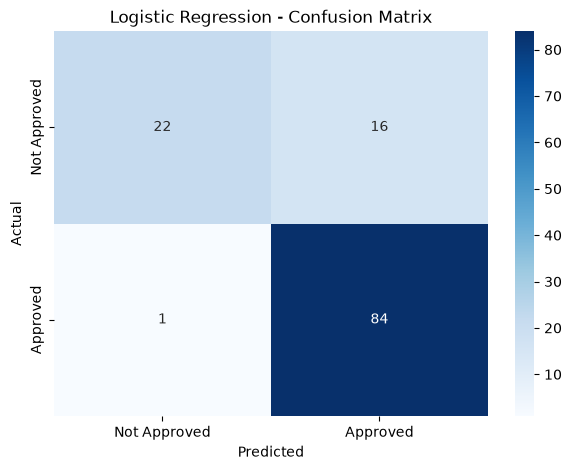

In [51]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Approved",
        "Approved"
    ],
    yticklabels=[
        "Not Approved",
        "Approved"
    ]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Cross-Validation Scores:")
print(cv_scores)

print(
    "Mean Cross-Validation Accuracy: {:.2%}".format(
        cv_scores.mean()
    )
)

Cross-Validation Scores:
[0.83838384 0.80612245 0.81632653 0.71428571 0.80612245]
Mean Cross-Validation Accuracy: 79.62%


## Conclusion

The Logistic Regression model was successfully developed to predict loan approval.
The dataset was explored, cleaned, and preprocessed before training the model.
The model was evaluated using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.
Overall, the project demonstrates a complete machine learning classification workflow.

The Logistic Regression model achieved an accuracy of 86.18% on the test data.
The model performed well in identifying approved loans, with a recall of 98.82%.
The F1 Score was 90.81% and the ROC-AUC score was 85.14%.
Overall, the model provides good performance for predicting loan approval.